In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

## 1️⃣ Dataset Overview

In [92]:
try:
    df = pd.read_csv("../data/raw/superstore.csv")
    print("✅ File Found Successfully\n")


except FileNotFoundError as e:
    print(f"❌ Sorry your file not found ")
    print(f"🔍 System Error Details :{e}")
    sys.exit(1)

print(f"Total Number of Rows :{df.shape[0]}")
print(f"Total Number of Columns :{df.shape[1]}")
print(f"Total Memory Usage by DataSet :{df.memory_usage(deep = True).sum()/1024:.2f}KB")


✅ File Found Successfully

Total Number of Rows :51290
Total Number of Columns :27
Total Memory Usage by DataSet :58797.21KB


## 2️⃣ Column Classification

In [103]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

datetime_cols = df.select_dtypes(include=['datetime64', 'datetime']).columns.tolist()


print("🔢 Numerical Columns Found:", len(numerical_cols))
print(numerical_cols, "\n")

print("🏷️ Categorical Columns Found:", len(categorical_cols))
print(categorical_cols, "\n")

print("⏰ Datetime Columns Found:", len(datetime_cols))
print(datetime_cols, "\n")


🔢 Numerical Columns Found: 9
['Discount', '记录数', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost', 'Year', 'weeknum'] 

🏷️ Categorical Columns Found: 18
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Region', 'Segment', 'Ship.Date', 'Ship.Mode', 'State', 'Sub.Category', 'Market2'] 

⏰ Datetime Columns Found: 0
[] 



## 3️⃣ Missing Values Report

In [77]:
for colum_name, missing_count in df.isnull().sum().items():
    print(f" {colum_name} : {missing_count}")

total_missing_values = df.isnull().sum().sum()
print(f"\nTotal Missing Values :{total_missing_values}")

 Category : 0
 City : 0
 Country : 0
 Customer.ID : 0
 Customer.Name : 0
 Discount : 0
 Market : 0
 记录数 : 0
 Order.Date : 0
 Order.ID : 0
 Order.Priority : 0
 Product.ID : 0
 Product.Name : 0
 Profit : 0
 Quantity : 0
 Region : 0
 Row.ID : 0
 Sales : 0
 Segment : 0
 Ship.Date : 0
 Ship.Mode : 0
 Shipping.Cost : 0
 State : 0
 Sub.Category : 0
 Year : 0
 Market2 : 0
 weeknum : 0

Total Missing Values :0


## 4️⃣ Duplicate Report

In [67]:
duplicate_rows = df.duplicated().sum()
print(f"Total Duplicate Row :{duplicate_rows}")

Total Duplicate Row :0


## 5️⃣ Cardinality Report

In [106]:
categorical_cols = df.select_dtypes(include = ["object", "category", "str"]).columns.tolist()

for col in categorical_cols:
    print(f"{col:<25} : {df[col].nunique()}")


Category                  : 3
City                      : 3636
Country                   : 147
Customer.ID               : 4873
Customer.Name             : 795
Market                    : 7
Order.Date                : 1430
Order.ID                  : 25035
Order.Priority            : 4
Product.ID                : 10292
Product.Name              : 3788
Region                    : 13
Segment                   : 3
Ship.Date                 : 1464
Ship.Mode                 : 4
State                     : 1094
Sub.Category              : 17
Market2                   : 6


## 6️⃣ Numerical Summary

In [91]:
df.describe()

,Discount,记录数,Order.Date,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,2013-05-11 21:26:49.155780,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
min,0.000000,1.0,2011-01-01 00:00:00,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,2012-06-19 00:00:00,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,2013-07-08 00:00:00,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,2014-05-22 00:00:00,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,2014-12-31 00:00:00,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000
std,0.212280,0.0,NaN,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795


## 7️⃣ Categorical Summary

In [107]:
df.describe(include = ["object", "str"])

,Category,City,Country,Customer.ID,Customer.Name,Market,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Region,Segment,Ship.Date,Ship.Mode,State,Sub.Category,Market2
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,3,3636,147,4873,795,7,1430,25035,4,10292,3788,13,3,1464,4,1094,17,6
top,Office Supplies,New York City,United States,JG-158051,Muhammed Yedwab,APAC,2014-06-18 00:00:00.000,CA-2014-100111,Medium,OFF-AR-10003651,Staples,Central,Consumer,2014-11-22 00:00:00.000,Standard Class,California,Binders,APAC
freq,31273,915,9994,40,108,11002,135,14,29433,35,227,11117,26518,130,30775,2001,6152,11002


## Initial Findings
- The DataSet contains 51290 rows and 27 columns.
- No missing values were found in DataSet.
- No duplicate rows were found.
- Date-related columns are currently stored as text and will require conversion before time-based analysis.
- High-cardinality columns such as Customer Name, Product Name, and Order ID indicate transactional-level data.

## 📈 Which product categories generate the highest total sales?

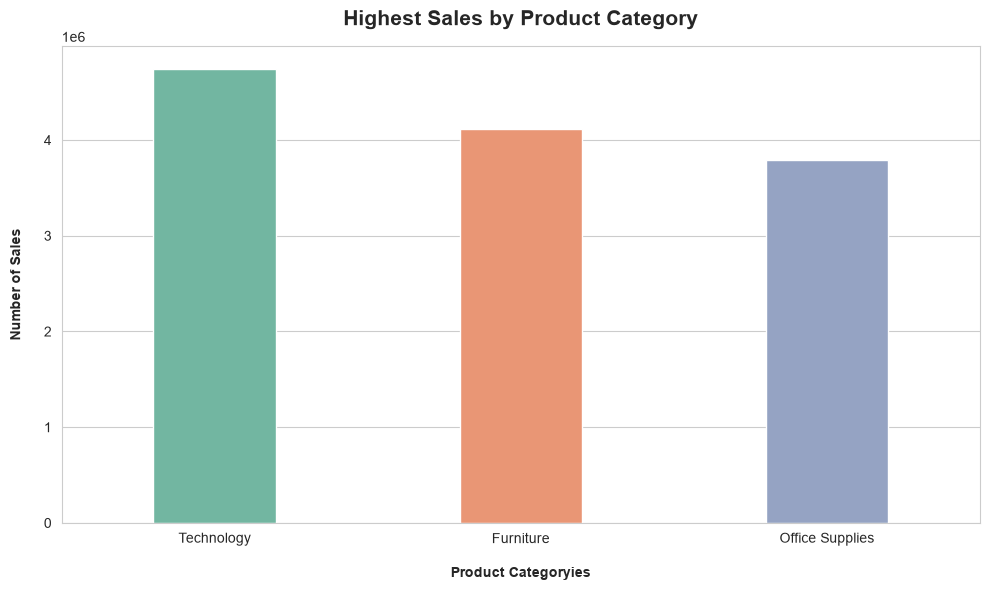

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize = (10, 6))

top_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending = False).reset_index()

sns.barplot(
    data = top_sales,
    y = "Sales",
    x = "Category",
    palette = "Set2",
    width = 0.4,
    errorbar = None,
    legend = False,
    hue = "Category"
)

plt.title("Highest Sales by Product Category", fontsize = 15, fontweight = "bold", pad = 15)

plt.xlabel("Product Categoryies", fontsize = 10, fontweight = "bold", labelpad = 15)
plt.ylabel("Number of Sales", fontsize = 10, fontweight = "bold", labelpad = 15)

plt.tight_layout()


plt.savefig("../images/highest_sales_by_product_category.png", dpi = 300, bbox_inches = "tight")
plt.show()


### 📊 Key Observations

* **Highest Sales:** The **Technology** category generates the highest total sales compared to all other product categories.
* **Runner-up:** **Furniture** ranks as the second highest contributor to total sales.
* **Lowest Sales:** **Office Supplies** contributes the least to overall sales among the three categories.

**💡 Summary:** Overall, **Technology** products bring in the most sales revenue for the business, followed by **Furniture**, while **Office Supplies** stands at the bottom.
